Loaded 33 calibration spectra with 7468 features each.
Loaded 4 solvent spectra.

Calibration dataset expanded to 561 samples (~4× original with solvent contamination).

Group K-Fold CV MAEs per fold: [0.07279198083652848, 0.08547785942886342, 0.10005645065227775, 0.05562901443201063, 0.04957749553418452]
Mean CV MAE: 0.0727

Testing 13 files...

Prediction for YH_2025_001_DCE_A.CSV: y = 0.5779
Prediction for YH_2025_001_DCE_B.CSV: y = 0.6435
Prediction for YH_2025_001_DCE_C.CSV: y = 0.5715
Prediction for YH_2025_001_DMSO_A.CSV: y = 0.9142
Prediction for YH_2025_001_DMSO_B.CSV: y = 0.8113
Prediction for YH_2025_001_DMSO_C.CSV: y = 0.8693
Prediction for YH_2025_001_HFIP_A.CSV: y = 0.3981
Prediction for YH_2025_001_HFIP_B.CSV: y = 0.4349
Prediction for YH_2025_001_HFIP_C.CSV: y = 0.5366
Prediction for YH_2025_001_HFIP_D.CSV: y = 0.3036
Prediction for YH_2025_001_Toluene_A.CSV: y = 0.5811
Prediction for YH_2025_001_Toluene_B.CSV: y = 0.6021
Prediction for YH_2025_001_Toluene_C.CSV: y = 0.

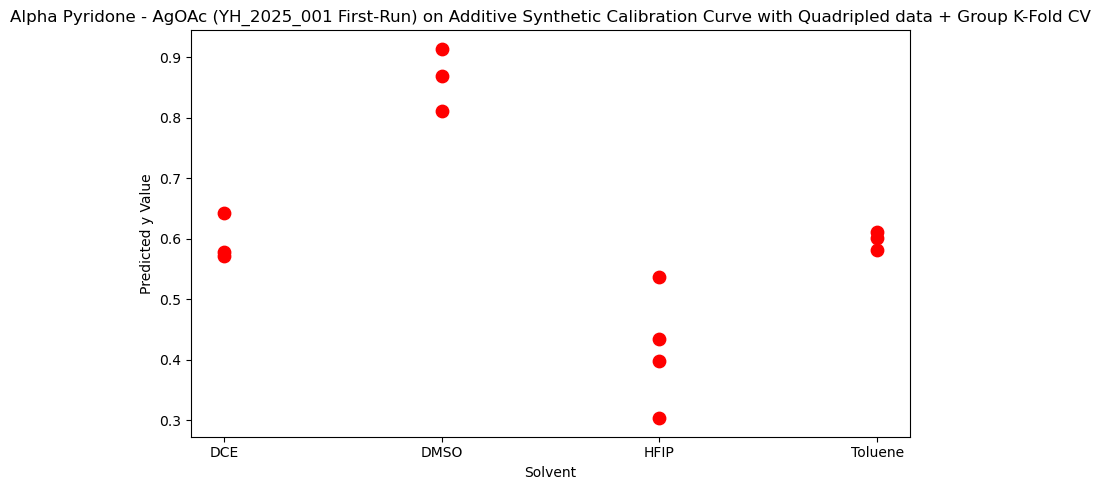

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_001/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5
k_folds = 5

def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    return calib + alpha * solvent
calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]
group_labels = [np.arange(len(y_calib))]

for solvent_spec in solvents.values():
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)
        group_labels.append(np.arange(len(y_calib)))

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
groups = np.concatenate(group_labels)
print(f"Calibration dataset expanded to {len(X_calib_all)} samples (~4× original with solvent contamination).\n")

gkf = GroupKFold(n_splits=k_folds)
cv_mae = []

for train_idx, val_idx in gkf.split(X_calib_all, y_calib_all, groups):
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_calib_all[train_idx], y_calib_all[train_idx])
    y_val_pred = pls.predict(X_calib_all[val_idx])
    cv_mae.append(mean_absolute_error(y_calib_all[val_idx], y_val_pred))

print(f"Group K-Fold CV MAEs per fold: {cv_mae}")
print(f"Mean CV MAE: {np.mean(cv_mae):.4f}\n")

pls_final = PLSRegression(n_components=n_components)
pls_final.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

results = []
predictions = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls_final.predict(test_spec.reshape(1, -1))[0])
    predictions.append((test_file, y_pred))
    results.append({'test_file': test_file, 'y_pred': y_pred})
    print(f"Prediction for {test_file}: y = {y_pred:.4f}")

pd.DataFrame(results).to_csv('synthetic_quadruple_additive_groupkfold_results.csv', index=False)
print("\nFull results saved to synthetic_quadruple_additive_groupkfold_results.csv")

solvent_order = ["DCE", "DMSO", "HFIP", "Toluene"]
y_values = [p[1] for p in predictions]
x_positions = []
x_labels = []
current_x = 0

for solvent in solvent_order:
    triplicate = [p for p in predictions if solvent in p[0]]
    for _ in triplicate:
        x_positions.append(current_x)
    x_labels.append(solvent)
    current_x += 1

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values, color='red', s=80)
plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('Alpha Pyridone - AgOAc (YH_2025_001 First-Run) on Additive Synthetic Calibration Curve with Quadripled data + Group K-Fold CV')
plt.tight_layout()
plt.show()

Loaded 33 calibration spectra with 7468 features each.
Loaded 4 solvent spectra.

Calibration dataset expanded to 561 samples (~4× original with solvent contamination).

Group K-Fold CV MAEs per fold: [0.07279198083652848, 0.08547785942886342, 0.10005645065227775, 0.05562901443201063, 0.04957749553418452]
Mean CV MAE: 0.0727

Testing 12 files...

Prediction for YH_2025_004_DCE_A.CSV: y = 0.5760
Prediction for YH_2025_004_DCE_B.CSV: y = 0.6084
Prediction for YH_2025_004_DCE_C.CSV: y = 0.5979
Prediction for YH_2025_004_DMSO_A.CSV: y = 0.8878
Prediction for YH_2025_004_DMSO_B.CSV: y = 0.7193
Prediction for YH_2025_004_DMSO_C.CSV: y = 0.9341
Prediction for YH_2025_004_HFIP_A.CSV: y = 0.2754
Prediction for YH_2025_004_HFIP_B.CSV: y = 0.2373
Prediction for YH_2025_004_HFIP_C.CSV: y = 0.1670
Prediction for YH_2025_004_Toluene_A.CSV: y = 0.6266
Prediction for YH_2025_004_Toluene_B.CSV: y = 0.6103
Prediction for YH_2025_004_Toluene_C.CSV: y = 0.6625

Full results saved to synthetic_quadruple_ad

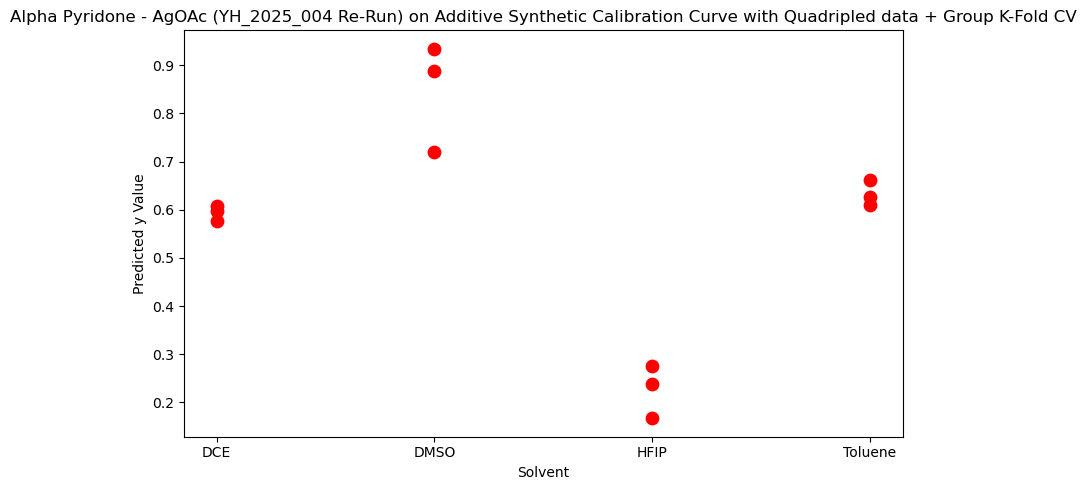

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_004/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]
alphas = np.arange(0.1, 0.5, 0.1)

n_components = 5
k_folds = 5

def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]
group_labels = [np.arange(len(y_calib))]

for solvent_spec in solvents.values():
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)
        group_labels.append(np.arange(len(y_calib)))

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
groups = np.concatenate(group_labels)
print(f"Calibration dataset expanded to {len(X_calib_all)} samples (~4× original with solvent contamination).\n")

gkf = GroupKFold(n_splits=k_folds)
cv_mae = []

for train_idx, val_idx in gkf.split(X_calib_all, y_calib_all, groups):
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_calib_all[train_idx], y_calib_all[train_idx])
    y_val_pred = pls.predict(X_calib_all[val_idx])
    cv_mae.append(mean_absolute_error(y_calib_all[val_idx], y_val_pred))

print(f"Group K-Fold CV MAEs per fold: {cv_mae}")
print(f"Mean CV MAE: {np.mean(cv_mae):.4f}\n")

pls_final = PLSRegression(n_components=n_components)
pls_final.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

results = []
predictions = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls_final.predict(test_spec.reshape(1, -1))[0])
    predictions.append((test_file, y_pred))
    results.append({'test_file': test_file, 'y_pred': y_pred})
    print(f"Prediction for {test_file}: y = {y_pred:.4f}")

pd.DataFrame(results).to_csv('synthetic_quadruple_additive_groupkfold_results.csv', index=False)
print("\nFull results saved to synthetic_quadruple_additive_groupkfold_results.csv")

solvent_order = ["DCE", "DMSO", "HFIP", "Toluene"]

y_values = [p[1] for p in predictions]
x_positions = []
x_labels = []
current_x = 0

for solvent in solvent_order:
    triplicate = [p for p in predictions if solvent in p[0]]
    for _ in triplicate:
        x_positions.append(current_x)
    x_labels.append(solvent)
    current_x += 1

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values, color='red', s=80)
plt.xticks(ticks=np.arange(len(x_labels)), labels=x_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('Alpha Pyridone - AgOAc (YH_2025_004 Re-Run) on Additive Synthetic Calibration Curve with Quadripled data + Group K-Fold CV')
plt.tight_layout()
plt.show()

Loaded 33 calibration spectra with 7468 features each.
Loaded 4 solvent spectra.

Generating synthetic calibration data for YH_2025_007_DEE...
Generating synthetic calibration data for YH_2025_007_DMSO...
Generating synthetic calibration data for YH_2025_007_IPA...
Generating synthetic calibration data for YH_2025_007_Water...
Calibration dataset expanded to 561 samples (≈ 4× original with solvent contamination).

Testing 12 files...

Prediction for YH_2025_012_DEE_A.CSV: y = 0.5292, MAE = 0.270764
Prediction for YH_2025_012_DEE_B.CSV: y = 0.5180, MAE = 0.282002
Prediction for YH_2025_012_DEE_C.CSV: y = 0.5502, MAE = 0.249767
Prediction for YH_2025_012_DMSO_A.CSV: y = 0.5768, MAE = 0.223210
Prediction for YH_2025_012_DMSO_B.CSV: y = 0.4742, MAE = 0.325811
Prediction for YH_2025_012_DMSO_C.CSV: y = 0.5246, MAE = 0.275388
Prediction for YH_2025_012_IPA_A(real).CSV: y = 0.6370, MAE = 0.163011
Prediction for YH_2025_012_IPA_B(real).CSV: y = 0.6222, MAE = 0.177822
Prediction for YH_2025_012

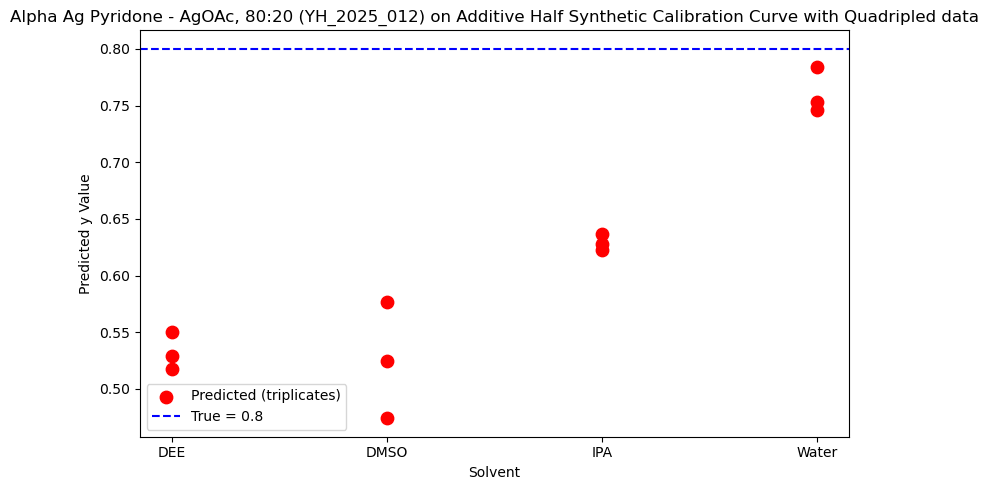

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5
true_y = 0.8

def load_spectrum(file_path):
    """Load 2nd column of CSV as spectrum."""
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    """Add solvent contamination (100% + α×solvent)."""
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating synthetic calibration data for {solvent_name}...")
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
print(f"Calibration dataset expanded to {len(X_calib_all)} samples (≈ 4× original with solvent contamination).\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((test_file, y_pred))
    maes.append(mae)
    
    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")

solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_positions = np.repeat(np.arange(len(solvent_labels)), 3)
y_values_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, color='red', s=80, label='Predicted (triplicates)')
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('Alpha Ag Pyridone - AgOAc, 80:20 (YH_2025_012) on Additive Half Synthetic Calibration Curve with Quadripled data')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})

Found 12 test files
YH_2025_012_DEE_A.CSV: y=0.5804, MAE=0.219643
YH_2025_012_DEE_B.CSV: y=0.5634, MAE=0.236562
YH_2025_012_DEE_C.CSV: y=0.6033, MAE=0.196682
YH_2025_012_DMSO_A.CSV: y=0.6473, MAE=0.152692
YH_2025_012_DMSO_B.CSV: y=0.4608, MAE=0.339182
YH_2025_012_DMSO_C.CSV: y=0.5563, MAE=0.243708
YH_2025_012_IPA_A(real).CSV: y=0.6982, MAE=0.101814
YH_2025_012_IPA_B(real).CSV: y=0.6606, MAE=0.139444
YH_2025_012_IPA_C(real).CSV: y=0.6621, MAE=0.137937
YH_2025_012_Water_A.CSV: y=0.7866, MAE=0.013401
YH_2025_012_Water_B.CSV: y=0.7966, MAE=0.003441
YH_2025_012_Water_C.CSV: y=0.7652, MAE=0.034837

Average MAE: 0.151612


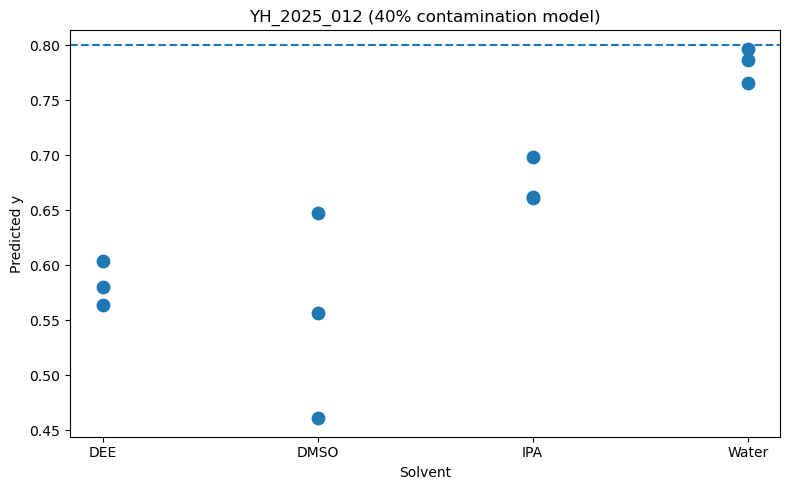

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/CD 2025 silver-pyridone calibration run/'  
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

n_components = 5
true_y = 0.8
alphas = np.arange(0.1, 0.5, 0.1)  # up to 40%

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]

y_values = [
    0.1,0.1,0.1,0,0,0,1,1,1,0.9,0.9,0.9,
    0.8,0.8,0.8,0.7,0.7,0.7,0.6,0.6,0.6,
    0.5,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.3,
    0.2,0.2,0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

# FUNCTIONS
def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    contaminated = calib + alpha * solvent
    return contaminated / (1 + alpha)

# LOAD CALIBRATION
calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values

# LOAD SOLVENTS
solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != X_calib.shape[1]:
        spec = np.interp(np.linspace(0,1,X_calib.shape[1]),
                         np.linspace(0,1,len(spec)), spec)
    solvents[file.split('.')[0]] = spec

# AUGMENT
X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    for alpha in alphas:
        X_synth = np.array([
            synthesize_spectrum(x, solvent_spec, alpha)
            for x in X_calib
        ])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_all = np.vstack(X_augmented)
y_all = np.concatenate(y_augmented)

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# MODEL
pls = PLSRegression(n_components=n_components)
pls.fit(X_all_scaled, y_all)

#Test
test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
])

print(f"Found {len(test_files)} test files")

if len(test_files) == 0:
    raise ValueError(f"No CSV test files found in: {test_dir}")

predictions = []
maes = []

for file in test_files:
    spec = load_spectrum(os.path.join(test_dir, file))[:X_calib.shape[1]]
    spec_scaled = scaler.transform(spec.reshape(1, -1))
    
    y_pred = float(pls.predict(spec_scaled)[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((file, y_pred))
    maes.append(mae)
    
    print(f"{file}: y={y_pred:.4f}, MAE={mae:.6f}")

if len(maes) > 0:
    print(f"\nAverage MAE: {np.mean(maes):.6f}")
else:
    print("\nNo predictions made — check test data.")

#PLOT
solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions = []
y_plot = []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_y, linestyle='--')

plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y')
plt.title('YH_2025_012 (40% contamination model)')
plt.tight_layout()
plt.show()